In [1]:
# --- INSTALL DEPENDENCIES ---------------------------------------------------
!pip install python-chess tensorflow numpy tqdm


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# --- IMPORTS ----------------------------------------------------------------
import os
import glob
import json
import numpy as np
import chess
import chess.pgn
import tensorflow as tf
import logging
import matplotlib.pyplot as plt
import random

from itertools import chain
from tqdm import tqdm

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler, EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import SparseCategoricalCrossentropy

from tensorflow.keras import regularizers
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import SparseTopKCategoricalAccuracy

import matplotlib.pyplot as plt

In [3]:
# Silence PGN parser messages
logging.getLogger('chess.pgn').setLevel(logging.CRITICAL)

# --- SETUP: Load only Lichess Elite PGNs from local folder -----------------
# Assumes the 'chess-ai' directory contains files named like lichess_elite_YYYY-MM.pgn
# We glob directly for that pattern and filter out any <1 KB pointer files.

pgn_root = 'chess-ai'
# Match files named lichess_elite_*.pgn anywhere under chess-ai
matched = glob.glob(os.path.join(pgn_root, '**', 'lichess_elite_*.pgn'), recursive=True)
# Exclude any very small files (<1 KB)
pgn_files = sorted(f for f in matched if os.path.getsize(f) > 1024)

if not pgn_files:
    print(f"Error: No lichess_elite_*.pgn files found under {pgn_root}.")
    raise SystemExit(1)

print(f"Loaded {len(pgn_files)} Lichess Elite PGN files for training:")
for f in pgn_files:
    print(f" - {os.path.basename(f)}")

Loaded 79 Lichess Elite PGN files for training:
 - lichess_elite_2013-09.pgn
 - lichess_elite_2013-11.pgn
 - lichess_elite_2014-01.pgn
 - lichess_elite_2014-02.pgn
 - lichess_elite_2014-03.pgn
 - lichess_elite_2014-04.pgn
 - lichess_elite_2014-05.pgn
 - lichess_elite_2014-06.pgn
 - lichess_elite_2014-07.pgn
 - lichess_elite_2014-08.pgn
 - lichess_elite_2014-09.pgn
 - lichess_elite_2014-10.pgn
 - lichess_elite_2014-11.pgn
 - lichess_elite_2014-12.pgn
 - lichess_elite_2015-01.pgn
 - lichess_elite_2015-02.pgn
 - lichess_elite_2015-03.pgn
 - lichess_elite_2015-04.pgn
 - lichess_elite_2015-05.pgn
 - lichess_elite_2015-06.pgn
 - lichess_elite_2015-07.pgn
 - lichess_elite_2015-08.pgn
 - lichess_elite_2015-09.pgn
 - lichess_elite_2015-10.pgn
 - lichess_elite_2015-11.pgn
 - lichess_elite_2015-12.pgn
 - lichess_elite_2016-01.pgn
 - lichess_elite_2016-02.pgn
 - lichess_elite_2016-03.pgn
 - lichess_elite_2016-04.pgn
 - lichess_elite_2016-05.pgn
 - lichess_elite_2016-06.pgn
 - lichess_elite_2016-07

In [ ]:
# --- PARAMETERS -------------------------------------------------------------
max_examples   = 200_000   # cap on positions to load
batch_size     = 512
epochs         = 25
learning_rate  = 0.001
show_progress  = True      # Toggle vocabulary-build progress display

In [5]:
# --- DATA PREPARATION -------------------------------------------------------
def board_to_tensor(board):
    tensor = np.zeros((8, 8, 12), dtype=np.int8)
    for sq, piece in board.piece_map().items():
        r, c = divmod(sq, 8)
        idx = piece.piece_type - 1
        if not piece.color:
            idx += 6
        tensor[r, c, idx] = 1
    return tensor


In [6]:
# --- BUILD MOVES VOCABULARY WITH CAPPED EXAMPLES ----------------------------
all_moves = set()
count = 0

pbar = tqdm(total=max_examples, desc="Building vocabulary")

random.shuffle(pgn_files)
for pgn in pgn_files:
    with open(pgn) as f:
        while count < max_examples:
            game = chess.pgn.read_game(f)
            if game is None:
                break
            for mv in game.mainline_moves():
                all_moves.add(mv.uci())
                count += 1
                pbar.update(1)
                if count >= max_examples:
                    break
        if count >= max_examples:
            break

pbar.close()

all_moves = sorted(all_moves)
vocabulary = {m: i for i, m in enumerate(all_moves)}
num_moves = len(all_moves)
print(f"Vocabulary size (capped at {max_examples} positions): {num_moves} distinct moves.")


with open("vocabulary.json", "w") as f:
    json.dump(vocabulary, f)

print("Saved vocabulary.json")


Building vocabulary: 100%|██████████| 200000/200000 [00:04<00:00, 46301.64it/s]

Vocabulary size (capped at 200000 positions): 1833 distinct moves.
Saved vocabulary.json


In [7]:
def data_generator(files, batch_size, max_examples=None):
    Xb, yb, count = [], [], 0
    for p in files:
        with open(p) as f:
            while True:
                game = chess.pgn.read_game(f)
                if not game:
                    break
                board = game.board()
                for mv in game.mainline_moves():
                    u = mv.uci()
                    # if it’s in the vocab, record it
                    if u in vocabulary:
                        Xb.append(board_to_tensor(board))
                        yb.append(vocabulary[u])
                        count += 1
                        if len(Xb) >= batch_size:
                            yield np.array(Xb, np.float32), np.array(yb, np.int32)
                            Xb, yb = [], []
                        if max_examples and count >= max_examples:
                            return

                    board.push(mv)

    if Xb:
        yield np.array(Xb, np.float32), np.array(yb, np.int32)


In [8]:
# Verify generator output
gen_iter = data_generator(pgn_files, batch_size, max_examples)
first = next(gen_iter, None)
if first is None:
    print("Error: No training data yielded; check your PGN files.")
    raise SystemExit(1)
train_gen = chain([first], gen_iter)

In [9]:
# --- SPLIT DATA INTO TRAIN AND VALIDATION SETS -----------------------------

# Shuffle files and split
random.shuffle(pgn_files)
split_idx = int(0.8 * len(pgn_files))
train_files = pgn_files[:split_idx]
val_files   = pgn_files[split_idx:]
print(f"Using {len(train_files)} files for training and {len(val_files)} for validation.")

Using 63 files for training and 16 for validation.


In [10]:
# Prepare tf.data.Datasets
def make_dataset(files):
    def gen():
        yield from data_generator(files, batch_size, max_examples)
    return tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec([None,8,8,12], tf.float32),
            tf.TensorSpec([None],      tf.int32)
        )
    ).repeat().prefetch(tf.data.AUTOTUNE)

# Create training and validation datasets
train_dataset = make_dataset(train_files)
val_dataset   = make_dataset(val_files)

In [11]:
# --- MODEL DEFINITION w/ BN, Dropout & L2 ---------------------------------
model = Sequential([
    tf.keras.Input((8, 8, 12)),

    # Conv block #1
    Conv2D(32, 3, padding='same',
           activation='relu',
           kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    MaxPool2D(2),

    # Conv block #2
    Conv2D(64, 3, padding='same',
           activation='relu',
           kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    MaxPool2D(2),

    # Global pooling + Dense with dropout
    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(512,
          activation='relu',
          kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.5),

    # Final policy head
    Dense(num_moves, activation='softmax')
])

# Use label-smoothing to prevent over-confidence
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=Adam(learning_rate),
    loss=loss_fn,
    metrics=['accuracy', SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)
model.summary()



callbacks = [
    # Stop if val_loss doesn’t improve for 15 epochs, and restore best weights
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),

    # Save only the best model
    ModelCheckpoint('best_chess_model.keras',
                    monitor='val_accuracy',
                    save_best_only=True,
                    verbose=1)
]

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1833)           │       940,329 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 995,977 (3.80 MB)

 Trainable params: 995,785 (3.80 MB)

 Non-trainable params: 192 (768.00 B)

Starting epoch 1/5

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/5


c:\Users\janni\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0454 - loss: 6.2287 - top_5_accuracy: 0.1160
Epoch 1: val_accuracy improved from None to 0.06317, saving model to best_chess_model.keras

Epoch 1: finished saving model to best_chess_model.keras
390/390 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.0455 - loss: 6.2274 - top_5_accuracy: 0.1162 - val_accuracy: 0.0632 - val_loss: 6.5470 - val_top_5_accuracy: 0.1451 - learning_rate: 0.0010
Starting epoch 2/5

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/5
389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0754 - loss: 5.7958 - top_5_accuracy: 0.1775
Epoch 2: val_accuracy improved from 0.06317 to 0.08485, saving model to best_chess_model.keras

Epoch 2: finished saving model to best_chess_model.keras
390/390 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.0755 - loss: 5.7947 - top_5_accuracy: 0.1776 - val_accuracy: 0.0848 - val_loss: 5.6958 - val_top_5_accuracy: 0.1948 - learning_rate: 0.0010
Starting

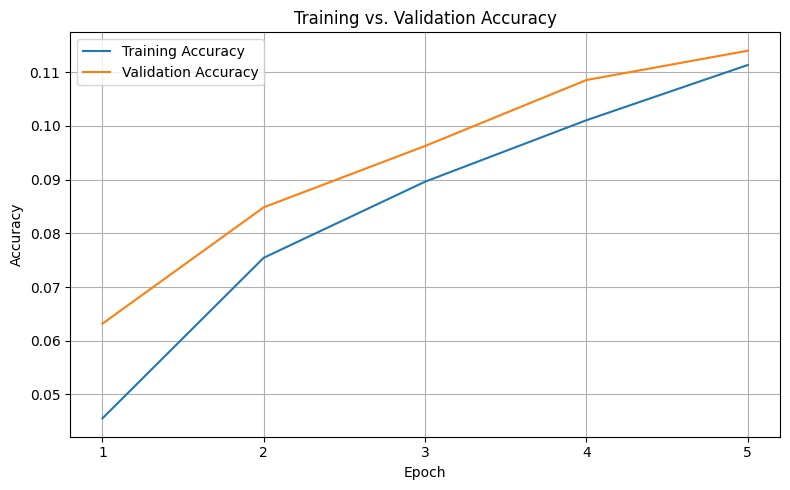

In [12]:
# --- TRAINING ---------------------------------------------------------------

# 1) Define your combined callbacks

# Print epoch start
epoch_cb = tf.keras.callbacks.LambdaCallback(
    on_epoch_begin=lambda e, logs: print(f"Starting epoch {e+1}/{epochs}")
)

# Reduce LR when training loss plateaus
lr_plateau_cb = ReduceLROnPlateau(
    monitor='loss', factor=0.5, patience=5, verbose=1
)

# Step‐decay schedule every 10 epochs
def step_decay(epoch):
    drop = 0.5
    epoch_drop = 10
    return learning_rate * (drop ** (epoch // epoch_drop))
lr_schedule_cb = LearningRateScheduler(step_decay, verbose=1)

# Early stopping on validation loss, restore best‐seen weights
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Save the single best model by validation accuracy
checkpoint_cb = ModelCheckpoint(
    'best_chess_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [
    epoch_cb,
    lr_plateau_cb,
    lr_schedule_cb,
    early_stopping_cb,
    checkpoint_cb
]

# 2) Compute steps
steps_per_epoch = max(1, max_examples // batch_size)
val_steps       = max(1, int((len(val_files)/len(pgn_files)) * max_examples // batch_size))

# 3) Train and capture history
history = model.fit(
    train_dataset,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=val_steps,
    verbose=1,
    callbacks=callbacks
)

# 4) Save final model (weights already best if early-stopped)
model.save('chess_ai_model.keras')

# --- PLOT ACCURACY ----------------------------------------------------------
train_acc = history.history['accuracy']
val_acc   = history.history['val_accuracy']
epochs_x  = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_x, train_acc, label='Training Accuracy')
plt.plot(epochs_x, val_acc,   label='Validation Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs_x)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
# --- TEST: Random Position and Top-5 Predictions (with legal-move masking + correct-move indicator) ---

with open("vocabulary.json", "r") as f:
    move_to_idx = json.load(f)

# 1) Pick random game & position


# Random PGN
# pgn_sample = random.choice(pgn_files)

# Pre-set shorter PGN
pgn_sample = "chess-ai/lichess_elite_2015-04.pgn"

with open(pgn_sample) as f:
    games = []
    while True:
        g = chess.pgn.read_game(f)
        if g is None:
            break
        games.append(g)

game = random.choice(games)
board = game.board()
moves = list(game.mainline_moves())
ply = random.randrange(len(moves))
for mv in moves[:ply]:
    board.push(mv)

correct_move = moves[ply]

print("Random test position from file:", os.path.basename(pgn_sample), f"(move {ply})")
print(board)
print(f"Correct move: {correct_move.uci()}")

# 2) Get the raw softmax probabilities
tensor = board_to_tensor(board)[None]
probs  = model.predict(tensor)[0]   # shape = (num_moves,)

# 3) Build a mask of legal moves
mask = np.zeros_like(probs)
legal = list(board.legal_moves)
for mv in legal:
    u = mv.uci()
    if u in move_to_idx:
        mask[ move_to_idx[u] ] = 1

# 4) Zero out illegal, then re-normalize over legal moves only
masked = probs * mask
if masked.sum() > 0:
    masked = masked / masked.sum()

# 5) Collect & sort top-5 legal moves by masked probability
legal_probs = [
    (mv, masked[move_to_idx[mv.uci()]])
    for mv in legal if mv.uci() in move_to_idx
]
legal_probs.sort(key=lambda x: x[1], reverse=True)

# 6) Display with correct-move indicator
print("Top 5 legal move predictions:")
found = False
for rank, (mv, p) in enumerate(legal_probs[:5], start=1):
    indicator = " <-- correct move" if mv == correct_move else ""
    print(f"  {rank}. {mv.uci():5s}  confidence={p:.4f}{indicator}")
    if mv == correct_move:
        found = True
if not found:
    print("(Correct move not in top 5 predictions)")


Random test position from file: lichess_elite_2015-04.pgn (move 8)
r . b q k b . r
p p p n . p p p
. . . . p n . .
. . . p . . . .
. . P P . . . .
. . N . . N . .
P P . . P P P P
R . B Q K B . R
Correct move: c1f4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Top 5 legal move predictions:
  1. c1g5   confidence=0.2915
  2. c4d5   confidence=0.2375
  3. e2e4   confidence=0.1171
  4. c1f4   confidence=0.1028 <-- correct move
  5. e2e3   confidence=0.0806
